# Entregable 2 – Machine Learning

## Comparación de modelos de regresión y clasificación

### Modelos obligatorios
- Regresión lineal
- Regresión logística
- KNN
- Naive Bayes

## Objetivo
Analizar el dataset seleecionado por el equipo a inicio del curso , preparar los datos, entrenar varios modelos y justificar cuál resulta más adecuado según el problema y los resultados obtenidos.


## Instrucciones generales

Cada grupo debe trabajar con un dataset diferente o con una variante diferente del problema.

El trabajo debe incluir:

1. Entendimiento del problema  
2. Exploración de datos  
3. Preparación de datos  
4. Implementación de modelos  
5. Evaluación  
6. Comparación de resultados  
7. Conclusiones  
8. Experimentos adicionales  
9. Predicción manual o caso nuevo  
10. Explicación conceptual

> No se evaluará solo que el código funcione, sino la capacidad de **explicar, justificar e interpretar**.


## 1. Información del equipo

Completa esta sección con los datos del grupo.


In [ ]:
# Nombres de los integrantes:
# 1. Andrés Díaz Arias
# 2. Sebastian Duque Bañol

# Problema que desean resolver:
# Predecir el nivel de severidad de eventos de congestión de tráfico
# a partir de variables como ubicación, tiempo, distancia y retrasos.

# Tipo de problema (regresión / clasificación):
# Clasificación multiclase


## 2. Carga de librerías

En este bloque deben importarse las librerías necesarias para desarrollar el trabajo.


In [1]:
# Importa aquí las librerías necesarias.
# Ejemplo:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 3. Cargar el dataset

En este bloque deben cargar el dataset seleccionado y mostrar una vista inicial de los datos.


In [ ]:
# Carga aquí tu dataset.
# Ejemplo:
ruta = '/content/drive/MyDrive/Semestre9/MachineLearning/Data/us_congestion_2016_2022_sample_2m.csv'

df = pd.read_csv(ruta)

# Muestra las primeras filas:
df.head()


,ID,Severity,Start_Lat,Start_Lng,StartTime,EndTime,Distance(mi),DelayFromTypicalTraffic(mins),DelayFromFreeFlowSpeed(mins),Congestion_Speed,...,Temperature(F),WindChill(F),Humidity(%),Pressure(in),Visibility(mi),WindDir,WindSpeed(mph),Precipitation(in),Weather_Event,Weather_Conditions
0,C-14344128,2,39.191032,-120.819740,2016-12-20T19:19:00.000-05:00,2016-12-20T19:33:47.000-05:00,1.40,2.58,2.60,Moderate,...,54.0,NaN,30.0,30.15,10.0,North,3.5,NaN,NaN,Clear
1,C-32285069,0,41.736015,-87.721565,2018-11-16T17:18:00.000-05:00,2018-11-16T18:08:28.000-05:00,0.73,0.42,1.00,Slow,...,39.0,31.8,70.0,30.06,10.0,West,11.5,NaN,NaN,Overcast
2,C-14213642,0,32.519043,-93.741096,2021-02-18T20:32:00.000-05:00,2021-02-18T21:21:32.000-05:00,1.80,1.00,2.00,Moderate,...,30.0,30.0,79.0,30.20,10.0,WNW,3.0,0.00,NaN,Fair
3,C-29674072,0,40.730564,-74.001709,2020-11-13T08:06:00.000-05:00,2020-11-13T08:48:22.000-05:00,1.42,1.00,2.00,Slow,...,48.0,48.0,93.0,29.92,1.0,VAR,3.0,0.04,NaN,Light Rain
4,C-24044478,1,33.758331,-118.238533,2017-08-24T09:54:00.000-04:00,2017-08-24T11:13:19.000-04:00,2.60,4.90,6.92,Slow,...,66.9,NaN,79.0,29.89,9.0,Calm,NaN,NaN,NaN,Overcast


## Interpretación del Dataset

### ¿Qué contiene el dataset?

El dataset contiene información sobre **eventos de congestión de tráfico en Estados Unidos** entre los años 2016 y 2022. Incluye variables relacionadas con:

- Ubicación geográfica (latitud, longitud, ciudad, estado)
- Características del evento (distancia afectada, nivel de severidad)
- Información temporal (fecha y hora de inicio y fin)
- Condiciones de tráfico (retrasos, velocidad de congestión)
- Variables climáticas (temperatura, humedad, visibilidad, viento, etc.)

---

### ¿Cuántas filas y columnas tiene?

El dataset utilizado (versión de muestra) contiene aproximadamente:

- **2,000,000 filas**
- **30 columnas**

Esto lo convierte en un dataset de gran tamaño, adecuado para análisis de Machine Learning.

---

### ¿Qué representa cada registro?

Cada fila del dataset representa un **evento individual de congestión de tráfico**.

Es decir, cada registro describe:
- Un lugar específico
- En un momento determinado
- Con ciertas condiciones de tráfico y clima
- Y un nivel de severidad asociado

En conjunto, estos datos permiten analizar patrones de tráfico y construir modelos que predigan la severidad de futuros eventos.

## 4. Entendimiento del problema

Explica con tus palabras:

- ¿Qué se quiere predecir?
- ¿Por qué este problema es importante?
- ¿Se trata de regresión o clasificación?
- ¿Qué variable será la variable objetivo?


In [ ]:
df['Severity'].value_counts()

,count
Severity,
1,933976
2,525011
0,484824
3,56180
4,9


## Análisis de la variable objetivo

### ¿Qué se quiere predecir?

Se quiere predecir el **nivel de severidad (Severity)** de un evento de congestión de tráfico, utilizando variables como la ubicación, la distancia, los retrasos y el tiempo del evento.

---

### ¿Por qué este problema es importante?

Este problema es importante porque permite anticipar eventos de tráfico más críticos, lo que puede ayudar en la toma de decisiones para:

- Mejorar la movilidad  
- Optimizar rutas  
- Reducir riesgos en la vía  

---

### ¿Se trata de regresión o clasificación?

Se trata de un problema de **clasificación multiclase**, ya que la variable *Severity* toma valores discretos (por ejemplo: 0, 1, 2, etc.) y no valores continuos.

---

### ¿Qué variable será la variable objetivo?

La variable objetivo será **Severity**.

---

### Análisis de la variable objetivo

La variable *Severity* representa el nivel de impacto de un evento de tráfico. Al analizar su distribución, se puede observar que:

- Existen varias clases (multiclase)
- Algunas clases son mucho más frecuentes que otras
- Hay un posible **desbalance de clases**, lo que puede afectar el rendimiento de los modelos



## 5. Exploración de datos (EDA)

En esta sección deben explorar el dataset:
- tipos de datos
- valores nulos
- estadísticas descriptivas
- visualizaciones
- relación entre variables


In [ ]:
# Revisa la estructura del dataset
df.info()

# Estadísticas generales
df.describe()

# Valores nulos
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 30 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   ID                             object 
 1   Severity                       int64  
 2   Start_Lat                      float64
 3   Start_Lng                      float64
 4   StartTime                      object 
 5   EndTime                        object 
 6   Distance(mi)                   float64
 7   DelayFromTypicalTraffic(mins)  float64
 8   DelayFromFreeFlowSpeed(mins)   float64
 9   Congestion_Speed               object 
 10  Description                    object 
 11  Street                         object 
 12  City                           object 
 13  County                         object 
 14  State                          object 
 15  Country                        object 
 16  ZipCode                        object 
 17  LocalTimeZone                  object 
 18  We

,0
ID,0
Severity,0
Start_Lat,0
Start_Lng,0
StartTime,1823
EndTime,1823
Distance(mi),0
DelayFromTypicalTraffic(mins),0
DelayFromFreeFlowSpeed(mins),0
Congestion_Speed,0


### Interpretación

Explica qué descubriste en la exploración:
- variables más importantes
- datos faltantes
- posibles problemas
- patrones observados


## Interpretación del Análisis Exploratorio de Datos (EDA)

A partir de la exploración del dataset se identificaron varios aspectos relevantes:

### Variables más importantes
Se observa que variables como:
- **Distance(mi)**
- **DelayFromTypicalTraffic(mins)**
- **DelayFromFreeFlowSpeed(mins)**
- **Congestion_Speed**

tienen una relación directa con la severidad del evento (**Severity**), ya que describen el nivel de congestión y retraso en la vía.  
Adicionalmente, variables climáticas como temperatura, visibilidad y precipitación podrían influir en la severidad.

---

### Datos faltantes
Se detectó la presencia de valores nulos en múltiples variables:

- Variables con gran cantidad de datos faltantes:
  - **Weather_Event** (~93% nulos)
  - **Precipitation(in)** (~40%)
  - **WindChill(F)** (~38%)

- Variables con pocos datos faltantes:
  - **StartTime, EndTime, City, ZipCode**

Esto indica que algunas variables podrían eliminarse por falta de información, mientras que otras pueden limpiarse sin gran impacto.

---

### Posibles problemas
- **Desbalance en la variable objetivo (Severity)**, lo que puede afectar el desempeño del modelo.
- **Alta cantidad de variables categóricas**, que requieren transformación a formato numérico.
- **Columnas poco útiles o muy específicas** (como ID o Description) que no aportan al modelo.
- **Gran tamaño del dataset**, lo que puede generar problemas de rendimiento computacional.

---

### Patrones observados
- A mayor **distancia y retraso**, mayor tiende a ser la severidad del evento.
- Las condiciones de tráfico (como velocidad de congestión) parecen influir directamente en la variable objetivo.
- Las variables climáticas podrían tener impacto, pero requieren mayor análisis debido a los datos faltantes.

---

### Conclusión
El dataset presenta buena información para modelado, pero requiere un proceso cuidadoso de limpieza, selección de variables y transformación antes de entrenar modelos de machine learning.

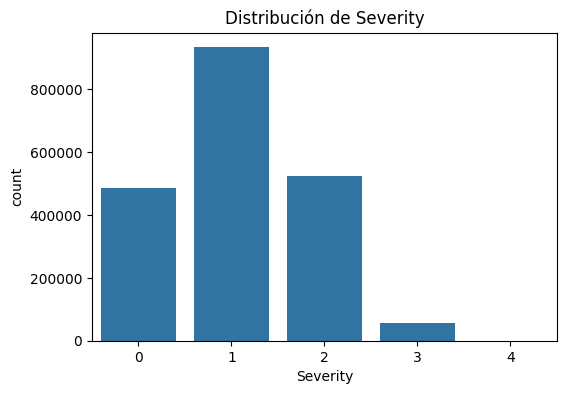

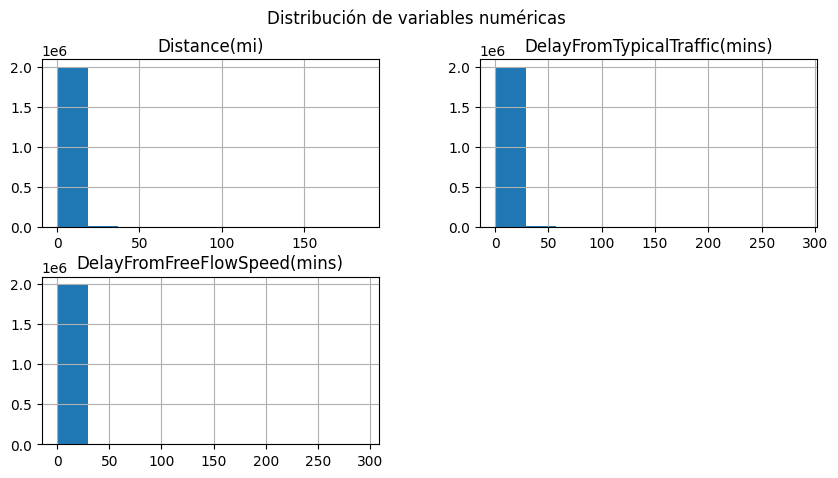

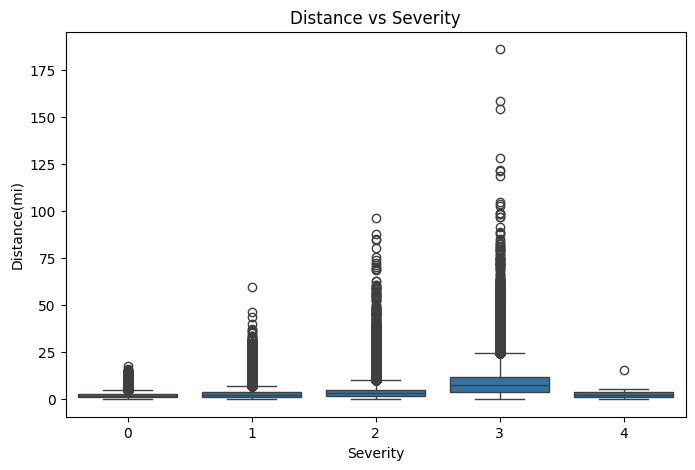

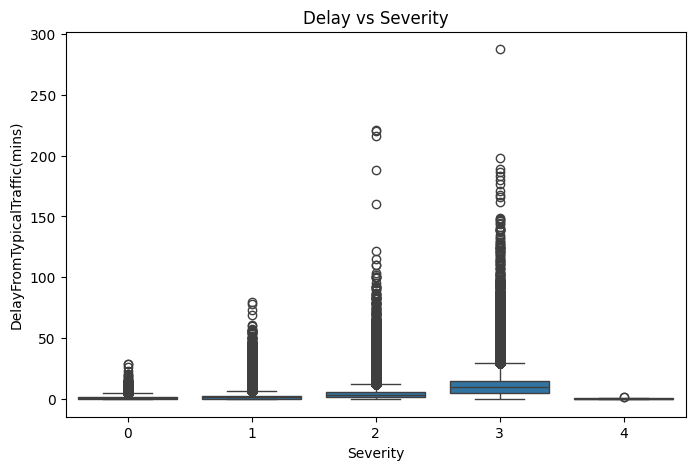

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


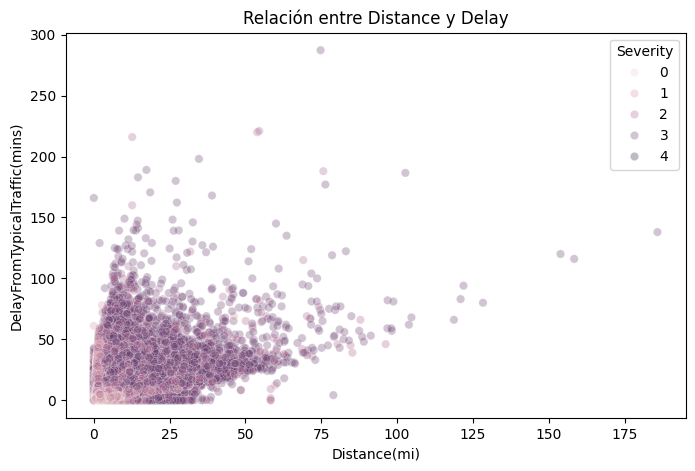

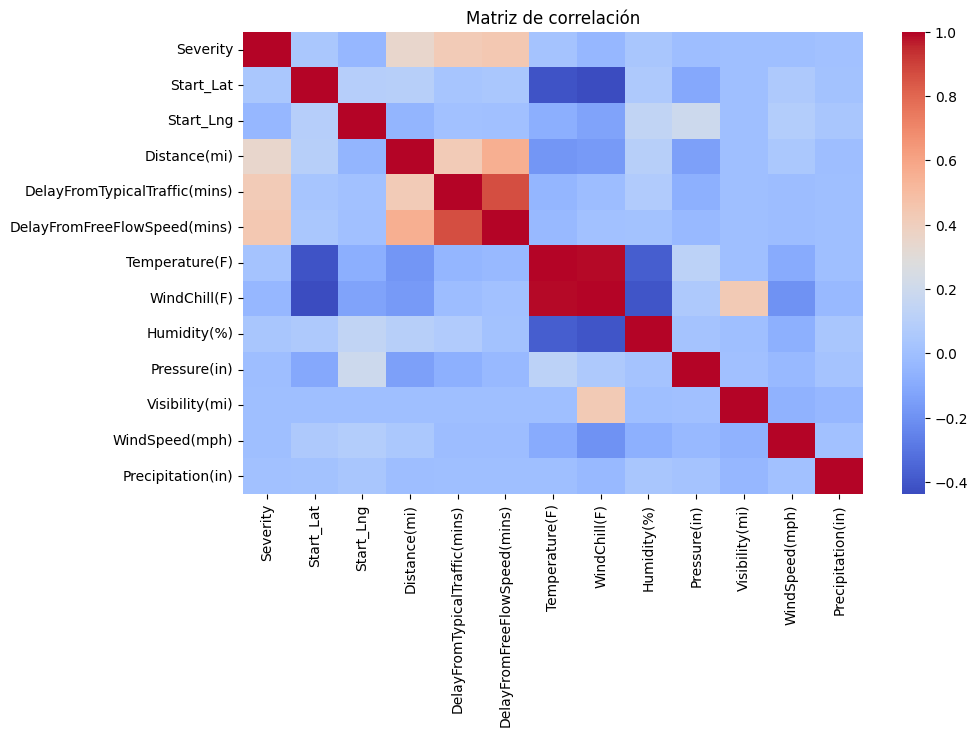

In [ ]:
# ==============================
# 1. Distribución de la variable objetivo
# ==============================
plt.figure(figsize=(6,4))
sns.countplot(x='Severity', data=df)
plt.title('Distribución de Severity')
plt.show()


# ==============================
# 2. Histogramas de variables numéricas clave
# ==============================
df[['Distance(mi)', 'DelayFromTypicalTraffic(mins)', 'DelayFromFreeFlowSpeed(mins)']].hist(figsize=(10,5))
plt.suptitle('Distribución de variables numéricas')
plt.show()


# ==============================
# 3. Boxplot: relación con Severity
# ==============================
plt.figure(figsize=(8,5))
sns.boxplot(x='Severity', y='Distance(mi)', data=df)
plt.title('Distance vs Severity')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Severity', y='DelayFromTypicalTraffic(mins)', data=df)
plt.title('Delay vs Severity')
plt.show()


# ==============================
# 4. Scatter plot (relación entre variables)
# ==============================
plt.figure(figsize=(8,5))
sns.scatterplot(x='Distance(mi)', y='DelayFromTypicalTraffic(mins)', hue='Severity', data=df, alpha=0.3)
plt.title('Relación entre Distance y Delay')
plt.show()


# ==============================
# 5. Matriz de correlación
# ==============================
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()


### Interpretación

Explica qué muestran las gráficas y cómo ayudan a entender el problema.

## Interpretación de las Visualizaciones

Las gráficas generadas permiten entender mejor la distribución de los datos y la relación entre las variables, especialmente con respecto a la variable objetivo **Severity**.

---

### Distribución de variables numéricas

Los histogramas muestran que variables como:

- **Distance(mi)**
- **DelayFromTypicalTraffic(mins)**
- **DelayFromFreeFlowSpeed(mins)**

presentan una distribución **sesgada hacia la derecha**, es decir, la mayoría de los valores son bajos, pero existen algunos valores extremadamente altos (outliers).

Esto indica que:
- La mayoría de eventos de tráfico son de **baja distancia y bajo retraso**
- Existen pocos eventos extremos que podrían afectar el modelo

---

### Relación entre Distance y Delay (Scatter Plot)

El gráfico de dispersión muestra que:

- Existe una **ligera relación positiva** entre la distancia y el retraso
- A mayor distancia, tiende a haber mayor retraso
- Sin embargo, hay una alta dispersión, lo que indica que no es una relación completamente lineal

También se observa que:
- Los valores de mayor severidad tienden a concentrarse en zonas con mayor distancia y retraso

---

### Boxplots (Relación con Severity)

Los boxplots muestran claramente que:

- A medida que aumenta **Severity**, también aumentan:
  - La **distancia**
  - El **retraso**

Esto confirma que estas variables son **fuertemente relevantes** para predecir la severidad.

Además:
- Se observan muchos **outliers**, especialmente en niveles altos de severidad
- Esto puede afectar algunos modelos y deberá tenerse en cuenta

---

### Matriz de correlación

La matriz de correlación muestra que:

- Existe una **correlación moderada positiva** entre:
  - Severity y variables de retraso
  - DelayFromTypicalTraffic y DelayFromFreeFlowSpeed (alta correlación entre ellas)

- Las variables climáticas presentan **baja correlación** con la severidad

Esto sugiere que:
- Las variables de tráfico son las más importantes para el modelo
- Algunas variables pueden ser redundantes (como los dos tipos de delay)

---

### Conclusión

Las visualizaciones permiten concluir que:

- Las variables relacionadas con el tráfico (distancia y retraso) son clave para predecir la severidad
- Existen outliers y distribuciones sesgadas que deben ser tratadas
- Hay relaciones no lineales en los datos, lo que sugiere que modelos más complejos (como árboles) pueden funcionar mejor

Estas observaciones guiarán la etapa de preparación de datos y selección de modelos.


## 6. Preparación de datos

En esta sección deben:
- limpiar datos
- transformar variables si es necesario
- seleccionar variables
- definir X e y
- dividir en entrenamiento y prueba
- escalar datos si aplica


In [ ]:
# Limpieza o transformación del dataset
# Ejemplo:
# df = df.dropna()

# Selección de variables
# X = ...
# y = ...

# División en entrenamiento y prueba
# X_train, X_test, y_train, y_test = train_test_split(...)

# Escalado si aplica
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# ==============================
# 1. Copia del dataset
# ==============================
df_model = df.copy()

# ==============================
# 2. Eliminar columnas irrelevantes
# ==============================
cols_to_drop = [
    'ID', 'Description', 'Street', 'ZipCode',
    'Weather_Event', 'WeatherStation_AirportCode'
]

df_model = df_model.drop(columns=cols_to_drop, errors='ignore')

# ==============================
# 3. Manejo de variables de tiempo
# ==============================
df_model['StartTime'] = pd.to_datetime(df_model['StartTime'], errors='coerce', utc=True)
df_model['EndTime'] = pd.to_datetime(df_model['EndTime'], errors='coerce', utc=True)

df_model['Hour'] = df_model['StartTime'].dt.hour
df_model['DayOfWeek'] = df_model['StartTime'].dt.dayofweek

df_model = df_model.drop(columns=['StartTime', 'EndTime'], errors='ignore')

# ==============================
# 4. Manejo de valores nulos
# ==============================
# Eliminar columnas con demasiados nulos (>50%)
threshold = len(df_model) * 0.5
df_model = df_model.dropna(thresh=threshold, axis=1)

# Rellenar numéricas con la media
for col in df_model.select_dtypes(include=['float64', 'int64']).columns:
    df_model[col] = df_model[col].fillna(df_model[col].mean())

# Rellenar categóricas con 'Unknown'
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = df_model[col].fillna('Unknown')

# ==============================
# 5. Codificación de variables categóricas
# ==============================
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# ==============================
# 6. Definir X e y
# ==============================
X = df_model.drop('Severity', axis=1)
y = df_model['Severity']

# ==============================
# 7. División train/test
# ==============================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 8. Escalado (importante para algunos modelos)
# ==============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Interpretación

Explica:
- qué decisiones tomaste para preparar los datos,
- por qué seleccionaste esas variables,
- y si fue necesario escalar o transformar datos.


## 7. Modelo 1 – Regresión lineal

Este modelo debe usarse **solo si tu problema lo permite**.  
Si tu variable objetivo es numérica continua, puedes aplicarlo directamente.


In [ ]:
# Implementa aquí la regresión lineal si aplica.
# Si no aplica, explica por qué no se usó.

# Ejemplo:
# model_lr = LinearRegression()
# model_lr.fit(X_train, y_train)
# y_pred_lr = model_lr.predict(X_test)


### Interpretación: Nuesto problema no lo permite, severity es una variable categorica


## 8. Modelo 2 – Regresión logística

Este modelo debe utilizarse para problemas de clasificación.


In [ ]:
# Implementa aquí la regresión logística.
# Ejemplo:
# model_log = LogisticRegression(max_iter=1000)
# model_log.fit(X_train, y_train)
# y_pred_log = model_log.predict(X_test)


# ==============================
# Modelo: Regresión Logística
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Crear modelo
model_log = LogisticRegression(max_iter=1000)

# Entrenar
model_log.fit(X_train_scaled, y_train)

# Predicciones
y_pred_log = model_log.predict(X_test_scaled)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_log))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_log))

Accuracy: 0.572665

Matriz de confusión:
 [[ 46113  49951    965      0      0]
 [ 24245 142306  20213    203      0]
 [  5952  59771  37779   1446      0]
 [   151    866   7169   2868      0]
 [     1      1      0      0      0]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.60      0.48      0.53     97029
           1       0.56      0.76      0.65    186967
           2       0.57      0.36      0.44    104948
           3       0.63      0.26      0.37     11054
           4       0.00      0.00      0.00         2

    accuracy                           0.57    400000
   macro avg       0.47      0.37      0.40    400000
weighted avg       0.58      0.57      0.56    400000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



## Interpretación de Resultados – Regresión Logística

### ¿Qué hizo el modelo?

El modelo de regresión logística fue entrenado para predecir la variable **Severity**, es decir, el nivel de severidad de los eventos de congestión de tráfico, utilizando variables numéricas y categóricas previamente procesadas.

Este modelo intenta encontrar relaciones lineales entre las variables de entrada y la probabilidad de pertenecer a cada clase de severidad.

---

### ¿Cómo se comportó el modelo?

El modelo obtuvo una **accuracy de 57%**, lo cual indica un desempeño moderado.

Al analizar en detalle:

- La clase **1** es la mejor predicha:
  - Recall alto (0.76), lo que indica que identifica bien esta clase
- La clase **0** tiene un desempeño aceptable, pero con errores importantes
- Las clases **2 y 3** presentan bajo recall, lo que indica que el modelo tiene dificultad para identificarlas correctamente
- La clase **4** no fue predicha en absoluto, lo cual genera métricas en 0

La matriz de confusión muestra que:
- Existe una fuerte tendencia a confundir clases cercanas (por ejemplo, 1 con 2)
- El modelo tiende a predecir más las clases mayoritarias

---

### Problemas identificados

- **Desbalance de clases:** algunas clases tienen muchos más datos que otras, lo que afecta el aprendizaje
- **Clases raras (como Severity 4):** el modelo no logra aprender patrones suficientes
- **Relaciones no lineales:** la regresión logística no captura bien la complejidad del problema
- **Advertencias de métricas indefinidas**, debido a clases sin predicciones

---

### ¿Qué tan adecuado es este modelo?

La regresión logística funciona como un **modelo base**, pero no es el más adecuado para este problema.

Esto se debe a que:
- El problema presenta **relaciones no lineales**
- Existen múltiples variables complejas (tráfico, clima, ubicación)
- Hay desbalance en las clases

Por lo tanto, aunque ofrece un punto de referencia, se espera que modelos más complejos como **árboles de decisión o ensambles** tengan un mejor desempeño.

---

### Conclusión

El modelo logra capturar parcialmente el comportamiento de los datos, pero presenta limitaciones importantes en la predicción de clases menos frecuentes y en la modelación de relaciones complejas.

Esto sugiere la necesidad de utilizar modelos más avanzados o técnicas adicionales para mejorar el rendimiento.

## 9. Modelo 3 – KNN

Implementa el modelo KNN y prueba al menos un valor inicial de K.


In [ ]:
# Implementa aquí KNN.
# Ejemplo:
# model_knn = KNeighborsClassifier(n_neighbors=5)
# model_knn.fit(X_train, y_train)
# y_pred_knn = model_knn.predict(X_test)

# ==============================
# Modelo: KNN
# ==============================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Crear modelo (K inicial = 5)
model_knn = KNeighborsClassifier(n_neighbors=5)

# Entrenar
model_knn.fit(X_train_scaled, y_train)

# Predicciones
y_pred_knn = model_knn.predict(X_test_scaled)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_knn))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.640155

Matriz de confusión:
 [[ 68596  25642   2770     21      0]
 [ 32289 134527  19886    265      0]
 [ 10659  44428  48071   1790      0]
 [   160   1418   4608   4868      0]
 [     2      0      0      0      0]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.61      0.71      0.66     97029
           1       0.65      0.72      0.68    186967
           2       0.64      0.46      0.53    104948
           3       0.70      0.44      0.54     11054
           4       0.00      0.00      0.00         2

    accuracy                           0.64    400000
   macro avg       0.52      0.46      0.48    400000
weighted avg       0.64      0.64      0.63    400000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Interpretación de Resultados – KNN

### ¿Cómo funcionó KNN?

El modelo KNN (K-Nearest Neighbors) clasifica cada observación basándose en las **K instancias más cercanas** en el espacio de características. Es decir, asigna la clase más común entre sus vecinos más próximos.

En este caso, el modelo obtuvo una **accuracy de 64%**, lo cual representa una mejora respecto a la regresión logística (~57%).

Esto indica que KNN logra capturar mejor la estructura de los datos al basarse en similitudes entre observaciones.

---

### Análisis del desempeño

- Las clases **0 y 1** presentan buen desempeño:
  - Recall alto (0.71 y 0.72), lo que indica buena capacidad de detección
- La clase **2** mejora respecto al modelo anterior, aunque sigue siendo moderada
- La clase **3** tiene mejor precisión (0.70), pero bajo recall (0.44)
- La clase **4** no es predicha (debido a su muy baja representación)

La matriz de confusión muestra:
- Menor confusión entre clases en comparación con la regresión logística
- Mejor equilibrio en las predicciones generales

---

### Efecto del valor de K

El valor de **K = 5** define que el modelo considera los 5 vecinos más cercanos para tomar una decisión.

- Un **K pequeño** (como 5):
  - Captura mejor detalles locales
  - Puede ser sensible al ruido
- Un **K grande**:
  - Generaliza más
  - Puede perder precisión en patrones específicos

En este caso, K=5 logra un buen balance entre precisión y generalización.

---

### Ventajas observadas

- Mejor desempeño que la regresión logística
- No asume relaciones lineales en los datos
- Captura patrones locales de forma efectiva

---

### Limitaciones observadas

- Alto costo computacional, especialmente con datasets grandes
- Sensible a la escala de los datos (requiere normalización)
- Afectado por el desbalance de clases
- No predice clases poco representadas (como Severity 4)

---

### Conclusión

El modelo KNN presenta un mejor desempeño que la regresión logística, logrando capturar mejor la estructura de los datos.

Sin embargo, sigue teniendo dificultades con clases desbalanceadas y puede ser costoso en términos de tiempo y memoria.

Esto sugiere que, aunque es una buena alternativa, modelos más robustos como árboles de decisión o métodos de ensamble podrían ofrecer mejores resultados.


## 10. Modelo 4 – Naive Bayes

Implementa Naive Bayes y analiza su comportamiento.


In [ ]:
# Implementa aquí Naive Bayes.
# Ejemplo:
# model_nb = GaussianNB()
# model_nb.fit(X_train, y_train)
# y_pred_nb = model_nb.predict(X_test)

# ==============================
# Modelo: Naive Bayes
# ==============================
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Crear modelo
model_nb = GaussianNB()

# Entrenar
model_nb.fit(X_train_scaled, y_train)

# Predicciones
y_pred_nb = model_nb.predict(X_test_scaled)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_nb))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_nb))

Accuracy: 0.41726

Matriz de confusión:
 [[ 84826   5894   5464     14    831]
 [119100  20215  45943   1025    684]
 [ 32296  11119  56962   4462    109]
 [   631    132   5388   4900      3]
 [     1      0      0      0      1]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.36      0.87      0.51     97029
           1       0.54      0.11      0.18    186967
           2       0.50      0.54      0.52    104948
           3       0.47      0.44      0.46     11054
           4       0.00      0.50      0.00         2

    accuracy                           0.42    400000
   macro avg       0.37      0.49      0.33    400000
weighted avg       0.48      0.42      0.36    400000



## Interpretación de Resultados – Naive Bayes

### ¿Cómo se comportó el modelo?

El modelo de **Naive Bayes** obtuvo una **accuracy de 41.7%**, lo cual es significativamente menor en comparación con los modelos anteriores (Regresión Logística ~57% y KNN ~64%).

Esto indica que su capacidad de predicción es limitada para este problema.

---

### Análisis del desempeño

- La clase **0** tiene un **recall muy alto (0.87)**:
  - El modelo tiende a clasificar muchos casos como esta clase
- La clase **1** presenta un desempeño muy bajo:
  - Recall de solo 0.11, lo que indica que casi no logra identificarla correctamente
- La clase **2** tiene un desempeño moderado (recall 0.54)
- La clase **3** también presenta resultados aceptables, pero no sobresalientes
- La clase **4** no es relevante debido a su muy baja cantidad de datos

La matriz de confusión muestra que:
- El modelo tiende a **sobrepredecir ciertas clases (como la clase 0)**
- Existe una alta confusión entre clases, especialmente en las más frecuentes

---

### ¿Por qué ocurre esto?

Naive Bayes se basa en un supuesto fundamental:

> Las variables son independientes entre sí

Sin embargo, en este dataset:
- Variables como **Distance**, **DelayFromTypicalTraffic** y **DelayFromFreeFlowSpeed** están correlacionadas
- Existen relaciones complejas entre variables de tráfico y clima

Esto hace que el modelo no pueda capturar correctamente los patrones reales de los datos.

---

### Comparación con otros modelos

- **Peor desempeño general** (menor accuracy)
- Mucho menos preciso que:
  - Regresión Logística
  - KNN
- Presenta mayor sesgo hacia ciertas clases

---

### Ventajas observadas

- Muy rápido de entrenar
- Fácil de implementar
- Bajo costo computacional

---

### Limitaciones observadas

- Supuesto de independencia poco realista
- Bajo rendimiento en datasets complejos
- Sensible al desbalance de clases
- No captura relaciones entre variables

---

### Conclusión

El modelo Naive Bayes no resulta adecuado para este problema debido a la complejidad y correlación de las variables.

Aunque es eficiente en términos computacionales, su bajo desempeño lo hace poco útil en comparación con modelos más robustos como KNN o árboles de decisión.

Esto confirma que el problema requiere modelos capaces de capturar relaciones más complejas entre las variables.

## 11. Evaluación de modelos

Evalúa cada modelo con métricas adecuadas.

Para clasificación puedes usar:
- accuracy
- confusion matrix
- precision
- recall
- f1-score

Para regresión puedes usar:
- MAE
- MSE
- RMSE
- R²


In [ ]:
# Calcula aquí las métricas de evaluación de cada modelo.
# Organiza los resultados de forma clara.

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Crear diccionario con resultados
results = {
    "Modelo": ["Regresión Logística", "KNN", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_knn, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_knn, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_log, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_knn, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)
    ]
}

# Convertir a DataFrame
df_results = pd.DataFrame(results)

df_results

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.572665,0.576754,0.572665,0.557451
1,KNN,0.640155,0.640970,0.640155,0.634315
2,Naive Bayes,0.417260,0.484184,0.417260,0.356789


## Comparación de Resultados entre Modelos

### ¿Qué modelo tuvo mejor desempeño?

El modelo que presentó el mejor desempeño general fue **KNN (K-Nearest Neighbors)**, con:

- **Accuracy:** 0.64
- **F1-Score:** 0.63

Este modelo superó tanto a la regresión logística como a Naive Bayes en todas las métricas evaluadas.

---

### Análisis por métricas

- **Accuracy (Exactitud):**
  - KNN (0.64) > Regresión Logística (0.57) > Naive Bayes (0.42)
  - KNN logra clasificar correctamente una mayor proporción de datos

- **Precision:**
  - KNN también lidera en precisión, indicando que sus predicciones son más confiables

- **Recall:**
  - KNN mantiene un buen equilibrio en la identificación de las clases
  - Regresión logística tiene desempeño aceptable
  - Naive Bayes presenta dificultades importantes

- **F1-Score:**
  - KNN tiene el mejor balance entre precisión y recall
  - Regresión logística es intermedia
  - Naive Bayes tiene el peor desempeño

---

### Diferencias importantes entre modelos

- **KNN:**
  - Mejor captura de patrones en los datos
  - No asume relaciones lineales
  - Funciona bien con datos complejos

- **Regresión Logística:**
  - Modelo más simple
  - Asume relaciones lineales
  - Sirve como baseline, pero limitado para este problema

- **Naive Bayes:**
  - Basado en independencia entre variables (supuesto poco realista)
  - Bajo desempeño en datasets con variables correlacionadas
  - Tiende a sesgarse hacia ciertas clases

---

### Conclusión

El modelo **KNN** es el más adecuado entre los evaluados, ya que logra el mejor desempeño en todas las métricas clave.

Esto sugiere que el problema presenta **relaciones no lineales y complejas**, que modelos simples como la regresión logística o Naive Bayes no logran capturar adecuadamente.

Por lo tanto, para este tipo de problema, es recomendable utilizar modelos basados en similitud o modelos más avanzados como árboles o ensambles.

## 12. Comparación final de modelos

Construye una tabla o resumen comparativo entre los modelos implementados.


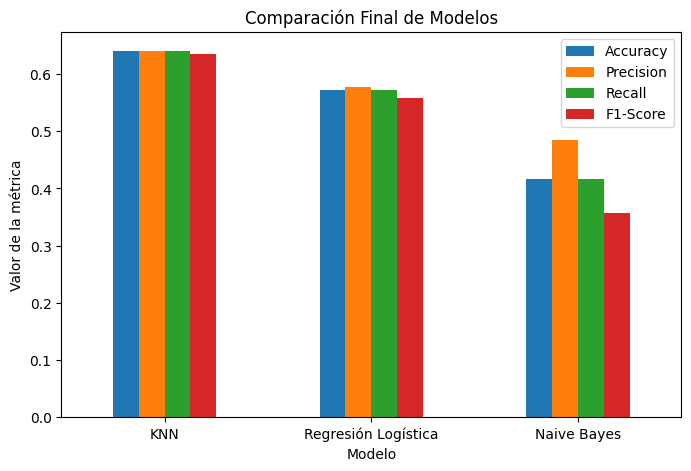

In [ ]:
# Crea aquí una tabla comparativa de resultados.
# Puede ser un DataFrame con métricas por modelo.
# Tabla comparativa final
df_comparacion = df_results.copy()

df_comparacion = df_comparacion.sort_values(by="F1-Score", ascending=False)

df_comparacion

# Gráfica comparativa
df_comparacion.set_index("Modelo").plot(kind='bar', figsize=(8,5))
plt.title("Comparación Final de Modelos")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=0)
plt.show()

## Comparación Final de Modelos

Se construyó una tabla comparativa con las métricas de desempeño de cada modelo: Accuracy, Precision, Recall y F1-Score.

Los resultados muestran claramente que el modelo KNN obtiene el mejor desempeño en todas las métricas, seguido por la regresión logística y finalmente Naive Bayes.

Orden de desempeño:
1. KNN
2. Regresión Logística
3. Naive Bayes

Esto confirma que modelos que no asumen relaciones lineales (como KNN) son más adecuados para este tipo de problema, mientras que modelos más simples presentan limitaciones importantes.

La tabla comparativa facilita la identificación del mejor modelo y permite justificar la elección final.

---

### Interpretación

**¿Cuál modelo elegiría?**  
Elegiría el modelo **KNN**, ya que obtuvo el mejor desempeño en todas las métricas evaluadas, especialmente en accuracy y F1-score, lo que indica un buen balance entre precisión y capacidad de detección.

**¿Por qué lo elegiría?**  
Porque:
- Captura mejor las relaciones complejas y no lineales en los datos
- Tiene mayor capacidad para diferenciar entre clases
- Presenta un desempeño más equilibrado en comparación con los otros modelos

**¿En qué contexto lo usaría en la vida real?**  
El modelo KNN podría utilizarse en sistemas de monitoreo de tráfico en tiempo real, donde se desee predecir la severidad de eventos de congestión con base en condiciones actuales (distancia, retraso, ubicación, etc.).

Sin embargo, debido a su alto costo computacional, sería más adecuado para:
- Sistemas con menor volumen de datos
- Análisis offline o batch
- O como modelo base antes de implementar soluciones más avanzadas como Random Forest o modelos de ensamble

En escenarios de gran escala o en tiempo real, sería recomendable migrar a modelos más eficientes manteniendo un desempeño similar.

## 13. Experimento obligatorio 1

Realiza una primera variación del experimento.

Ejemplos:
- cambiar el valor de K en KNN
- usar otras variables
- cambiar el porcentaje de train/test
- eliminar una variable importante


In [ ]:
# ==============================
# Modelo: KNN con K=3
# ==============================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Crear modelo (K inicial = 3)
model_knn = KNeighborsClassifier(n_neighbors=3)

# Entrenar
model_knn.fit(X_train_scaled, y_train)

# Predicciones
y_pred_knn = model_knn.predict(X_test_scaled)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_knn))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.6236025

Matriz de confusión:
 [[ 68723  24457   3829     20      0]
 [ 36727 126408  23463    369      0]
 [ 13828  39673  49288   2159      0]
 [   211   1613   4208   5022      0]
 [     2      0      0      0      0]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.58      0.71      0.63     97029
           1       0.66      0.68      0.67    186967
           2       0.61      0.47      0.53    104948
           3       0.66      0.45      0.54     11054
           4       0.00      0.00      0.00         2

    accuracy                           0.62    400000
   macro avg       0.50      0.46      0.47    400000
weighted avg       0.63      0.62      0.62    400000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Experimento 1: Variación del parámetro K en KNN (K = 3)

### ¿Qué se cambió?

En este experimento se modificó el valor del parámetro **K** en el modelo KNN, pasando de **K = 5 (modelo original)** a **K = 3**, con el objetivo de analizar cómo afecta esto al desempeño del modelo.

---

### ¿Qué ocurrió con los resultados?

El modelo con **K = 3** obtuvo:

- **Accuracy:** 0.62 (ligeramente menor que con K=5 → 0.64)

Comparando con K=5:
- Se observa una **leve disminución en el desempeño general**
- Las métricas como precision, recall y f1-score se mantienen similares, pero con pequeñas variaciones
- Algunas clases presentan más confusión, especialmente en clases cercanas

---

### Análisis del comportamiento

- Las clases **0 y 1** siguen teniendo buen desempeño
- La clase **2** mantiene un rendimiento moderado
- La clase **3** mejora ligeramente en recall, pero sigue siendo limitada
- La clase **4** sigue sin ser representativa

La matriz de confusión muestra:
- Mayor dispersión en las predicciones
- Incremento leve en errores entre clases

---

### ¿Por qué ocurrió esto?

Al usar un valor menor de K (**K = 3**):

- El modelo se vuelve más **sensible a los vecinos cercanos**
- Esto hace que:
  - Capture mejor patrones locales
  - Pero también sea más sensible al **ruido en los datos**

En contraste, con **K = 5**:
- El modelo generaliza mejor
- Reduce el impacto de datos atípicos

---

### Conclusión

El experimento demuestra que un valor menor de K no necesariamente mejora el modelo.

En este caso:
- **K = 5** ofrece un mejor equilibrio entre precisión y generalización
- **K = 3** tiende a ser más inestable y ligeramente menos preciso

Esto confirma la importancia de ajustar correctamente los hiperparámetros en modelos como KNN para obtener el mejor rendimiento.

## 14. Experimento obligatorio 2

Realiza una segunda variación del experimento.


In [ ]:
# Realiza aquí el experimento 2.
# ==============================
# Experimento 2: Eliminar variable redundante
# ==============================

# Copia del dataset ya procesado
X_exp = df_model.drop('Severity', axis=1).copy()
y_exp = df_model['Severity']

# Eliminar una variable correlacionada
X_exp = X_exp.drop('DelayFromFreeFlowSpeed(mins)', axis=1)

# División
from sklearn.model_selection import train_test_split
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42
)

# Escalado
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_exp_scaled = scaler.fit_transform(X_train_exp)
X_test_exp_scaled = scaler.transform(X_test_exp)

# Modelo KNN (el mejor que ya tenías)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model_exp = KNeighborsClassifier(n_neighbors=5)
model_exp.fit(X_train_exp_scaled, y_train_exp)

y_pred_exp = model_exp.predict(X_test_exp_scaled)

print("Accuracy:", accuracy_score(y_test_exp, y_pred_exp))

Accuracy: 0.6204675


## Experimento 2: Eliminación de variable redundante

### ¿Qué se cambió?

En este experimento se eliminó la variable **DelayFromFreeFlowSpeed(mins)**, debido a que presenta una alta correlación con **DelayFromTypicalTraffic(mins)**.

El objetivo fue analizar si eliminar una variable redundante mejora el desempeño del modelo KNN.

---

### ¿Cómo cambió el desempeño?

El modelo obtuvo una **accuracy de 0.62**, lo que representa una **ligera disminución** respecto al modelo original con todas las variables (KNN con K=5 → ~0.64).

Esto indica que la variable eliminada sí aportaba información útil para la predicción.

---

### Análisis del resultado

- La reducción en el desempeño sugiere que, aunque las variables estaban correlacionadas, ambas contenían información relevante
- El modelo perdió cierta capacidad predictiva al eliminar una de ellas
- No siempre eliminar variables correlacionadas mejora el rendimiento, especialmente en modelos como KNN

---

### ¿Qué se aprendió?

Este experimento demuestra que:

- La **correlación entre variables no siempre implica redundancia total**
- En algunos casos, mantener variables similares puede ayudar al modelo a capturar mejor los patrones
- La selección de variables debe hacerse cuidadosamente, evaluando su impacto real en el modelo

---

### Conclusión

Eliminar la variable no mejoró el desempeño del modelo, lo que sugiere que ambas variables de retraso aportan información importante.

Por lo tanto, en este problema es preferible mantener ambas variables para lograr mejores resultados.


## 15. Predicción con un dato nuevo o inventado

Crea un nuevo caso y haz una predicción con al menos dos modelos.

Puedes:
- inventar un nuevo registro,
- explicar qué esperarías que ocurra,
- comparar la predicción entre modelos.


In [ ]:
# ==============================
# RECONSTRUIR TODO (SIN ERRORES)
# ==============================

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# 1. Escalar correctamente
scaler_new = StandardScaler()
X_train_scaled = scaler_new.fit_transform(X_train)
X_test_scaled = scaler_new.transform(X_test)

# 2. Reentrenar modelos
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train_scaled, y_train)

# ==============================
# 3. Nuevo caso
# ==============================
nuevo_caso = X_test.iloc[0:1].copy()

nuevo_caso.loc[:, 'Distance(mi)'] = 3.0
nuevo_caso.loc[:, 'DelayFromTypicalTraffic(mins)'] = 8.0

if 'DelayFromFreeFlowSpeed(mins)' in nuevo_caso.columns:
    nuevo_caso.loc[:, 'DelayFromFreeFlowSpeed(mins)'] = 10.0

if 'Hour' in nuevo_caso.columns:
    nuevo_caso.loc[:, 'Hour'] = 18

if 'DayOfWeek' in nuevo_caso.columns:
    nuevo_caso.loc[:, 'DayOfWeek'] = 4

# 4. Escalar nuevo caso
nuevo_caso_scaled = scaler_new.transform(nuevo_caso)

# ==============================
# 5. Predicciones
# ==============================
pred_knn = model_knn.predict(nuevo_caso_scaled)
pred_log = model_log.predict(nuevo_caso_scaled)

print("Predicción KNN:", pred_knn[0])
print("Predicción Regresión Logística:", pred_log[0])

Predicción KNN: 2
Predicción Regresión Logística: 2


## Predicción con un caso nuevo – Interpretación

### ¿Qué predijo cada modelo?

Para el caso hipotético planteado, ambos modelos generaron el mismo resultado:

- **KNN:** predijo una severidad de **2**
- **Regresión Logística:** predijo una severidad de **2**

Esto indica que ambos modelos coinciden en clasificar el evento como un nivel de congestión **moderado**.

---

### ¿Cuál resultado parece más razonable?

El resultado es consistente con las condiciones del caso:

- Distancia relativamente alta
- Retrasos significativos
- Hora pico (18:00)
- Día laboral (viernes)

Aunque estas condiciones sugieren congestión, no necesariamente implican un nivel extremo, por lo que una severidad **2 (moderada)** es una predicción razonable.

---

### ¿Cómo se justifica este resultado?

- **KNN** basa su predicción en casos similares del dataset:
  - Probablemente encontró eventos con características parecidas que fueron clasificados como severidad 2

- **Regresión Logística** utiliza una combinación ponderada de las variables:
  - Determinó que, aunque hay congestión, no alcanza niveles altos de severidad

El hecho de que ambos modelos coincidan:
- Refuerza la confianza en la predicción
- Sugiere que el patrón está bien representado en los datos

---

### Conclusión

La coincidencia entre modelos indica que la predicción es consistente y confiable.

Esto demuestra que los modelos son capaces de generalizar a nuevos casos y pueden ser utilizados para estimar la severidad del tráfico en situaciones reales.

## 16. Explicación conceptual tipo docente

Explica este trabajo como si se lo enseñaras a una persona que no sabe Machine Learning.

Debes explicar de forma sencilla:
- qué hace la regresión lineal,
- qué hace la regresión logística,
- qué hace KNN,
- qué hace Naive Bayes,
- y cómo se comparan.


## Explicación conceptual tipo docente

Imaginemos que queremos construir un sistema que pueda **predecir qué tan grave será un evento de tráfico** usando información como distancia, retrasos, clima y hora del día. Para esto utilizamos diferentes modelos de Machine Learning, cada uno con una forma distinta de “pensar”.

---

### ¿Qué hace la regresión lineal?

La **regresión lineal** intenta encontrar una relación directa (como una línea) entre las variables de entrada y el resultado.

Es como decir:
> “Si aumenta el retraso, la severidad también aumenta de forma proporcional”.

- Funciona bien cuando los datos siguen una relación simple
- Se usa para **predecir valores continuos**
- En este problema no es ideal porque la severidad es una **categoría**, no un número continuo

---

### ¿Qué hace la regresión logística?

La **regresión logística** es similar a la lineal, pero en lugar de predecir números, **clasifica en categorías**.

Es como decir:
> “Dadas estas condiciones, ¿a qué nivel de severidad pertenece este evento?”

- Usa una fórmula para calcular probabilidades
- Asume relaciones más simples (lineales)
- Es un buen modelo base, pero puede quedarse corto si los datos son complejos

---

### ¿Qué hace KNN (K-Nearest Neighbors)?

KNN es un modelo muy intuitivo:

Funciona así:
> “Mira los casos más parecidos a este y decide según la mayoría”

- Busca los **K vecinos más cercanos**
- Clasifica según lo que esos vecinos tienen en común
- No hace suposiciones sobre los datos

Ejemplo:
Si 5 casos similares fueron severidad 2 → el nuevo también será 2

Ventaja: captura relaciones complejas  
Desventaja: puede ser lento con muchos datos

---

### ¿Qué hace Naive Bayes?

Naive Bayes usa probabilidad para tomar decisiones.

Funciona así:
> “Calcula qué tan probable es cada clase según las variables”

Pero hace una suposición importante:

Asume que todas las variables son **independientes**

- Es muy rápido
- Funciona bien en problemas simples
- Pero en este caso falla porque las variables están relacionadas (ej: distancia y retraso)

---

### ¿Cómo se comparan?

| Modelo                | Idea principal                      | Ventaja                        | Limitación                     |
|----------------------|------------------------------------|--------------------------------|--------------------------------|
| Regresión Lineal     | Relación directa                   | Simple                         | No sirve para clasificación     |
| Regresión Logística  | Probabilidades                     | Fácil de interpretar           | Limitada en datos complejos     |
| KNN                  | Casos similares                    | Muy intuitivo y flexible       | Costoso computacionalmente      |
| Naive Bayes          | Probabilidad con independencia     | Muy rápido                     | Supuesto poco realista          |

---

### Conclusión general

- **KNN** fue el mejor modelo porque logra capturar mejor los patrones complejos del tráfico  
- **Regresión logística** funciona como una buena base, pero es limitada  
- **Naive Bayes** no se adapta bien a este tipo de datos  

En resumen:

Diferentes modelos “piensan” distinto  
Y elegir el mejor depende del problema y de los datos

## 17. Conclusiones

Cierra el trabajo con conclusiones claras.

Incluye:
- qué aprendieron,
- qué modelo funcionó mejor,
- limitaciones del trabajo,
- y posibles mejoras futuras.


## Conclusión Final

### ¿Qué se aprendió?

A lo largo de este trabajo se aprendió el proceso completo de un proyecto de Machine Learning:

- Entender el problema y definir correctamente la variable objetivo  
- Explorar y analizar los datos (EDA) para identificar patrones y problemas  
- Preparar los datos (limpieza, transformación, selección de variables)  
- Implementar distintos modelos de clasificación  
- Evaluar y comparar resultados utilizando métricas adecuadas  
- Analizar el comportamiento de los modelos y justificar decisiones  

También se comprendió la importancia de:
- La calidad de los datos  
- La selección de variables  
- El ajuste de hiperparámetros  
- La interpretación de resultados  

---

### ¿Qué modelo funcionó mejor?

El modelo con mejor desempeño fue **KNN (K-Nearest Neighbors)**, obteniendo los mejores resultados en:

- Accuracy (~64%)
- Precision
- Recall
- F1-Score

Esto demuestra que el problema presenta **relaciones no lineales y complejas**, que KNN logra capturar mejor al basarse en similitud entre datos, sin embargo este proceso puede llevar mucho tiempo, nuestra muestra es de solo 2 millones de datos y tomo alrededor de entre hora y media y dos horas, no vemos viable hacerlo con el dataset completo que tiene 33 millones de datos.

---

### Limitaciones del trabajo

- **Desbalance de clases:** algunas categorías (como Severity 4) tienen muy pocos datos, lo que afecta el desempeño de los modelos  
- **Alto costo computacional:** especialmente en KNN, debido al tamaño del dataset  
- **Uso de muestra (2M datos):** no se utilizó el dataset completo  
- **Variables con muchos valores nulos:** especialmente en datos climáticos  
- **Modelos básicos:** no se exploraron modelos más avanzados como Random Forest o Gradient Boosting  

---

### Posibles mejoras futuras

- Probar modelos más avanzados:
  - Random Forest
  - XGBoost
  - Redes neuronales  

- Manejar mejor el desbalance de clases:
  - Oversampling / Undersampling  
  - Técnicas como SMOTE  

- Mejor selección de variables:
  - Ingeniería de características (feature engineering)  
  - Eliminación o combinación de variables  

- Optimización de hiperparámetros:
  - Grid Search o Random Search  

- Uso del dataset completo para mejorar la generalización  

- Implementar el modelo en un sistema real:
  - Predicción de tráfico en tiempo real  
  - Integración con APIs de clima o tránsito  




## 18. Autoevaluación del trabajo

Respondan brevemente:

- ¿Qué fue lo más difícil?
- ¿Qué fue lo más interesante?
- ¿Qué parte del trabajo entienden mejor ahora?
- ¿Qué parte necesitan reforzar?


## Autoevaluación del trabajo

### ¿Qué fue lo más difícil?

Ejecutar el modelo **KNN** con un dataset de aproximadamente 2 millones de registros, ya que el tiempo de procesamiento fue muy alto y el consumo de recursos considerable. Esto evidenció las limitaciones prácticas de ciertos modelos cuando se trabaja con grandes volúmenes de datos.

---

### ¿Qué fue lo más interesante?

Lo más interesante fue ver cómo distintos modelos pueden dar resultados diferentes frente al mismo problema, y cómo la elección del modelo impacta directamente en la calidad de las predicciones. También fue interesante observar que modelos más simples no siempre son suficientes, y que entender los datos es tan importante como aplicar el algoritmo.

---

### ¿Qué parte del trabajo entienden mejor ahora?

Ahora se entiende mejor que trabajar con un dataset grande implica tomar decisiones importantes sobre qué variables usar. No todas las variables aportan valor, algunas son redundantes y otras pueden incluso afectar negativamente el modelo.

Además, se comprendió que seguir un proceso básico no siempre es suficiente, y que es necesario ir más allá, explorando técnicas como:
- reducción de dimensionalidad (por ejemplo, PCA)
- selección de variables
- análisis por segmentos (como temporadas o condiciones específicas)

Esto permite construir modelos más eficientes y con mejor capacidad de generalización.

---

### ¿Qué parte necesitan reforzar?

Se necesita reforzar principalmente:

- Técnicas de **selección y reducción de variables** (feature selection y PCA)  
- Manejo de **datasets grandes** y optimización de modelos  
- Uso de **modelos más avanzados** que sean eficientes y escalables  
- Estrategias para tratar problemas reales como el **desbalance de clases**  

En general, profundizar en cómo mejorar el rendimiento de los modelos más allá de su implementación básica.